# Probabilistic cell typing

This notebooks guides you through the integration of ISS data with pre-existing clustered and annotated scRNAseq datasets, using Probabilistic Cell Typing (PCIseq).

Please have a look at:
https://www.nature.com/articles/s41592-019-0631-4
https://github.com/acycliq/pciSeq


Using this method, and if the genes measured by ISS have been accurately chosen for the task, it is possible to link these 2 modalities, and put on a geographical map the clusters inferred by scRNAseq in a coupled dataset.

## Import the necessary modules

In [1]:
import ISS_postprocessing.pciseq as PCIseq

# --- Core imports ---
from pathlib import Path
import numpy as np
import pandas as pd

# --- Image I/O and processing ---
from tifffile import imread, imwrite
from scipy.sparse import load_npz, coo_matrix
from skimage.segmentation import mark_boundaries, find_boundaries
from skimage.morphology import disk
from scipy.ndimage import binary_dilation

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns


## Read the single cell RNA sequencing dataset

In this step we can either input a clustered scRNAseq object, or even just a table with the average expression data per cluster.

In [2]:
sc_file = '/path/to/sc_file.csv/'

In [3]:
sc_file = ('/mnt/DATA/ext_home/saga/mean_expression_sc_gallus_input_for_pciseq_82genes.csv')

In [4]:
scRNAseq = pd.read_csv(sc_file, header=None, index_col=0, compression=None, dtype=object)
scRNAseq = scRNAseq.rename(columns=scRNAseq.iloc[0], copy=False).iloc[1:]
scRNAseq = scRNAseq.astype(float)


In [5]:
# We can show the data to have a look and confirm everything looks as it should.
scRNAseq

,PTN,WNT7B,VWF,ALCAM,CD47,EPHA3,OLIG2,RSPH1,AQP1,ADARB2,...,TNC,CCL4,GALNT17,COL1A1,TOP2A,PAX7,NEFM,SV2A,NHLH1,NFIX
0,,,,,,,,,,,,,,,,,,,,,
Astrocytes,3.587947,0.030573,0.041456,0.677526,0.771675,0.390175,0.244626,0.391348,0.069255,0.011017,...,1.849384,0.362311,0.028139,0.205104,0.396486,0.000505,0.064681,0.002534,0.022889,0.366377
Microglia,1.286048,0.003528,0.048740,0.758927,1.102061,0.287784,0.152681,0.139150,0.057442,0.008727,...,0.117937,3.674492,0.016774,0.068619,0.229527,0.000000,0.041104,0.005995,0.029968,0.065405
NeuralProgenitors,3.493644,0.012284,0.057419,0.318924,0.156899,0.198860,0.413668,0.118902,0.034963,0.010011,...,0.435557,0.560390,0.035196,0.047492,1.497565,0.000000,0.137240,0.016250,0.032604,0.295874
Oligodendrocytes,3.561084,0.007737,0.044362,0.949213,0.586661,0.163051,3.128700,0.117238,0.047443,0.131206,...,0.123586,0.425375,0.013819,0.084626,0.571907,0.000000,0.079418,0.039228,0.017175,0.277096
OtherCells,2.844307,0.010368,0.021499,0.263620,0.443067,0.975745,0.063699,1.505146,0.112546,0.015873,...,0.529970,0.189084,0.009472,2.335470,0.426167,0.001177,0.119593,0.001446,0.029880,0.404520
Vascular,1.347583,0.005661,0.733105,0.100350,0.534872,0.123196,0.128158,0.175393,0.889046,0.008869,...,0.145448,0.433182,0.025198,0.829059,0.441080,0.000000,0.066698,0.004054,0.024742,0.078623
ckGABA-01,1.120819,0.028090,0.056151,0.824739,1.872094,1.257088,0.129756,0.210019,0.286749,0.025599,...,0.141736,0.385226,0.027911,0.115789,0.101629,0.000000,0.082254,0.025856,0.015283,0.192404
ckGABA-02,1.112609,0.790983,0.021781,1.560177,0.901814,0.471168,0.162315,0.190004,0.364139,1.294179,...,0.098702,0.487819,0.070240,0.061209,0.130518,0.000000,0.090083,0.111748,0.027783,0.588846
ckGABA-03,1.098566,0.083079,0.066116,0.780726,0.643485,0.521575,0.196832,0.171375,0.121413,0.255326,...,0.296452,0.445134,0.018150,0.057714,0.091788,0.000000,0.171464,0.030895,0.024085,0.078594


## Import the segmentation mask and the ISS data

In the following steps, we first load the two main inputs required for building the ISS–scRNAseq integration dataset:  

- **Segmentation mask** (`coo_file`):  
  A sparse label image (saved in `.npz` format) where each pixel is assigned to a cell ID. This defines the spatial boundaries of individual cells.  

- **Decoded ISS spots** (`spots_file`):  
  A table (CSV or similar) with the coordinates and gene identities of all decoded spots. Each spot will later be assigned to a cell in the segmentation mask.  

Together, these inputs are combined to construct a spatially resolved **gene-by-cell count matrix**.  

---

## Preprocessing the spots

Before running PCIseq, the ISS spots must be preprocessed and aligned with the scRNAseq dataset:  

1. **Filter spots by quality**  
   Spots can be filtered using various quality metrics. Please refer to the manual for details about available metrics and recommended thresholds.  

2. **Coordinate conversion**  
   - If ISS spot coordinates are already in **pixels**, use `conversion_factor = 1`.  
   - If coordinates are in **micrometers**, convert them into pixel units (to match the segmentation mask) using `conversion_factor = 0.1625`.  

3. **Gene intersection**  
   To ensure comparability, we restrict both ISS and scRNAseq data to the set of genes present in *both* modalities. Genes absent from one dataset are not informative for integration and are excluded.  

---

## Data flow

Here’s how the pieces fit together in the pipeline:  

**Decoded ISS spots** (`spots_file`)  
&nbsp;&nbsp;⬇ filter + convert + gene intersection  
**Segmentation mask** (`coo_file`)  
&nbsp;&nbsp;⬇ assign spots → cells  
**scRNAseq reference**  
&nbsp;&nbsp;⬇ restrict to shared genes  

➡️ **Spatial gene-by-cell matrix** → input to **PCIseq**  

---

### Input Parameters

- **`input_dir`** *(str)*: Path to the parent directory containing the **preprocessed region folders**  
  (e.g., `/R1/`, `/R2/`, …). These folders are created automatically during preprocessing.  

- **`region`** *(str)*: Region identifier to process (e.g., `"R1"`).  

- **`DAPI_ch`** *(int, default = 4)*: Index of the **DAPI channel** in the raw images (0-based).  
  Example: `DAPI_ch = 4` loads the file `Cycle1_ch4.tif`.  

- **`segmentation_method`** *(str)*: Segmentation backend to use: `"cellpose"` or `"stardist"`.  
  Must match the mask file you saved earlier during segmentation.


---

> **Note:** In this notebook, **only one region is processed at a time**.  
> The variable `region` must be a **single string** (e.g., `"R1"`), not a list of regions as in earlier pipeline steps.  



In [6]:
input_dir = '/path/to/regions/'
region = 'R1'
DAPI_ch = 4
segmentation_method = 'cellpose' 

In [7]:
input_dir =  '/mnt/DATA/ext_home/saga/test/saga/output_tif_autosaved/redlionfish/'
region = 'R1'
segmentation_method = 'cellpose' 
dense = True


Loaded segmentation mask: /mnt/DATA/ext_home/saga/test/saga/output_tif_autosaved/redlionfish/R1/postprocessing/segmentation/R1_cellpose_expanded.npz
 - Shape: (2052, 3924), 508 cells
Loaded spots file: /mnt/DATA/ext_home/saga/test/saga/output_tif_autosaved/redlionfish/R1/decoding/2_decoded_dense/R1_decoded.csv
 - Spots: 52039
Found 0 overlapping genes.
scrnaseq_clean shape: (16, 0)
processed_spots_clean shape: (0, 3)


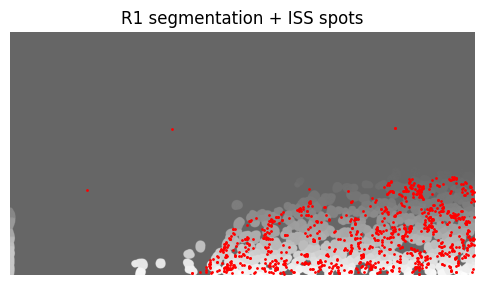

In [8]:
coo, processed_spots_clean, scrnaseq_clean = PCIseq.preprocess_inputs(
    input_dir, 
    region, segmentation_method, scRNAseq, dense=True, quality_threshold=0.5, conversion_factor=1
)


## Running PCIseq

Now we can finally run the **Probabilistic Cell Typing (PCIseq)** algorithm.  
This step integrates the ISS decoded spots with the segmentation mask and the 
reference scRNA-seq dataset to probabilistically assign each segmented cell to 
a transcriptional cell type.  

> **Note:** The current Python implementation can be quite slow, so please allow sufficient 
> time for the computation, especially when working with large datasets or many regions.


In [ ]:
PCIseq.run_pciseq(
    input_dir, 
    region,
    processed_spots_clean,   # filtered + cleaned ISS spots
    coo,                     # segmentation mask in COO format
    scrnaseq_clean,          # scRNAseq reference (overlap only)
    save_output=True
    )


# Read the PCIseq output and plot the data

PCIseq is **probabilistic** in two important ways:  
1. It calculates the probability of each cell belonging to a specific cell type (or another).  
2. It calculates the probability of each ISS spot being assigned to a given cell (or another).  

After running PCIseq, the following three output files are generated in the region’s `postprocessing/PCIseq/` folder:  

- **`most_probable.csv`**  
  A table listing each segmented cell with its `(x, y)` position, the most probable assigned cell type, and the probability of that assignment.  

- **`geneData.json`**  
  A spot-level table showing which cell each spot has been assigned to, along with the assignment probability.  

- **`cellData.json`**  
  A more detailed cell-level table that includes secondary probabilities, assignment distributions across possible cell types, and other metadata.  

We begin by reading the **`most_probable.csv`** file.


In [ ]:
PCIseq_dir = Path(input_dir) / region / "postprocessing" / "PCIseq"
pcifile = PCIseq_dir / 'most_probable.csv'
pciout = pd.read_csv(pcifile)

The `pciout['ClassName']` column will contain the primary assignment for each cell, and the `pciout['Prob']` will contain the probability of that assignment.

For each cluster, we can plot the cells, together with their color-coded PCIseq probability using the following code:

In [ ]:

# Loop over all unique assigned cell types
for cluster in pciout['ClassName'].unique():
    print(f"Plotting cluster: {cluster}")
    
    # Subset cells belonging to this cluster
    pcigene = pciout.loc[pciout['ClassName'] == cluster]
    
    # Create scatterplot (X, Y = spatial coords, colored by probability)
    plt.figure(figsize=(12, 12))
    sns.scatterplot(
        x="X", y="Y",
        hue="Prob", data=pcigene,
        palette="rainbow", s=5, edgecolor=None, alpha=0.8
    )
    
    # Titles and styling
    plt.title(f"PCIseq assignment probabilities - {cluster}", fontsize=16)
    plt.xlabel("X coordinate (pixels)")
    plt.ylabel("Y coordinate (pixels)")
    plt.legend(title="Probability", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.axis("equal")  # keep spatial aspect ratio
    plt.show()
